# FASE 3: Ingesta y almacenamiento de datos IoT en InfluxDB

### Santiago Mosquera y Samuel Rengifo

**Proyecto:** Sistema de monitoreo de sensores IoT y analítica de datos agroclimáticos para agricultura digital  
**Cultivos:** Caña de azúcar (Valle del Cauca) y Arroz (Tolima, Casanare)  
**Curso:** Sistemas y Comunicaciones I — Universidad ICESI  
**Fase:** 3 — Ingesta y almacenamiento de datos IoT en TSDB

---

## Objetivo

Implementar un pipeline de ingesta IoT que capture los mensajes MQTT publicados por el simulador de la Fase 2, los procese a través de un Gateway IoT (Node-RED), y los almacene en una base de datos de series de tiempo (InfluxDB v2). El resultado es una base de datos consultable con todas las observaciones de las 4 parcelas listas para análisis posterior.

## Arquitectura

```
Simulador Python (Fase 2)
        │ MQTT publish QoS=1
        ▼
Eclipse Mosquitto              (broker MQTT — localhost:1883)
        │ MQTT subscribe (agricultura/#)
        ▼
Node-RED Gateway               (gateway IoT — localhost:1880)
        │ HTTP write API
        ▼
InfluxDB v2                    (TSDB — localhost:8086)
    org=agricultura, bucket=agro_iot_data, measurement=sensor_data
```

## Entregables del laboratorio

| # | Entregable | Archivo / Evidencia |
|---|---|---|
| 1 | Captura del flow Node-RED implementado | `evidencia_nodered_flow.png` |
| 2 | Configuración del broker MQTT (Mosquitto) | `evidencia_mosquitto_config.png` |
| 3 | Base de datos creada en InfluxDB | `evidencia_influxdb_bucket.png` |
| 4 | Evidencia de almacenamiento de datos | `evidencia_influxdb_data_explorer.png` |
| 5 | Consulta mostrando registros almacenados | sección 5 de este notebook |

---
## 1. Verificación de prerrequisitos

Antes de ejecutar las celdas siguientes, asegúrate de tener corriendo:

1. **Mosquitto** en `localhost:1883` (Fase 2).
2. **InfluxDB v2** en `localhost:8086` con la organización `agricultura` y el bucket `agro_iot_data` creados (paso 2.3 de `INSTALACION_INFLUXDB_NODERED.md`).
3. **Node-RED** en `localhost:1880` con el flow `flow_node_red.json` importado y desplegado.
4. **Token de InfluxDB** generado y configurado en el nodo InfluxDB Out de Node-RED.
5. **Cliente Python `influxdb-client`** para consultar la base de datos desde aquí.

Para instalar el cliente Python:

```bash
pip install influxdb-client pandas
```

In [ ]:
# Verificación de paquetes y servicios locales
import os
import sys
import socket
import urllib.request
from pathlib import Path

# 1) Cliente InfluxDB
try:
    from influxdb_client import InfluxDBClient, Point, WritePrecision
    from influxdb_client.client.write_api import SYNCHRONOUS
    print('✓ influxdb-client disponible')
except ImportError:
    print('✗ influxdb-client no instalado. Ejecutar: pip install influxdb-client')

# 2) Pandas
try:
    import pandas as pd
    print(f'✓ pandas {pd.__version__}')
except ImportError:
    print('✗ pandas no instalado.')

# 3) Verificar conectividad a Mosquitto
def puerto_abierto(host, port, timeout=2):
    try:
        with socket.create_connection((host, port), timeout=timeout):
            return True
    except (socket.timeout, ConnectionRefusedError, OSError):
        return False

for nombre, host, port in [('Mosquitto MQTT', 'localhost', 1883),
                              ('InfluxDB',       'localhost', 8086),
                              ('Node-RED',       'localhost', 1880)]:
    estado = '✓ corriendo' if puerto_abierto(host, port) else '✗ NO responde'
    print(f'  {nombre:18s} {host}:{port:5d} {estado}')

# 4) Verificar archivo de flow
if Path('flow_node_red.json').exists():
    print('✓ flow_node_red.json disponible para importar')
else:
    print('⚠ flow_node_red.json no se encuentra en el directorio actual')

✓ influxdb-client disponible
✓ pandas 3.0.2
  Mosquitto MQTT     localhost: 1883 ✓ corriendo
  InfluxDB           localhost: 8086 ✓ corriendo
  Node-RED           localhost: 1880 ✓ corriendo
✓ flow_node_red.json disponible para importar


---
## 2. Configuración de la conexión a InfluxDB

Configuramos las credenciales de InfluxDB. **Ya que nunca se pone el token en código** — se usa una variable de entorno o un archivo `.env`.

In [ ]:
# Configuración (usando variables de entorno por seguridad)
INFLUX_URL    = os.environ.get('INFLUX_URL', 'http://localhost:8086')
INFLUX_ORG    = os.environ.get('INFLUX_ORG', 'agricultura')
INFLUX_BUCKET = os.environ.get('INFLUX_BUCKET', 'agro_iot_data')
INFLUX_TOKEN  = os.environ.get('INFLUX_TOKEN', '<TOKEN_AQUI>')

print('Configuración:')
print(f'  URL:    {INFLUX_URL}')
print(f'  Org:    {INFLUX_ORG}')
print(f'  Bucket: {INFLUX_BUCKET}')
print(f'  Token:  {"<configurado>" if INFLUX_TOKEN != "<TOKEN_AQUI>" else "⚠ FALTA — configurar variable INFLUX_TOKEN o editar la celda"}')

# Para configurar el token desde aquí (solo en desarrollo local):
# os.environ['INFLUX_TOKEN'] = 'tu-token-aqui'
# INFLUX_TOKEN = os.environ['INFLUX_TOKEN']

Configuración:
  URL:    http://localhost:8086
  Org:    agricultura
  Bucket: agro_iot_data
  Token:  <configurado>


---
## 3. Validación de la conexión y del bucket

Verificamos que podemos conectarnos a InfluxDB y que el bucket destino existe.

In [ ]:
# Conectar y verificar el bucket
try:
    client = InfluxDBClient(url=INFLUX_URL, token=INFLUX_TOKEN, org=INFLUX_ORG)
    health = client.health()
    print(f'✓ Health: {health.status} (versión: {health.version})')

    # Listar buckets
    buckets_api = client.buckets_api()
    buckets = buckets_api.find_buckets().buckets
    print(f'\nBuckets disponibles en la organización {INFLUX_ORG!r}:')
    for b in buckets:
        marca = ' ◄ TARGET' if b.name == INFLUX_BUCKET else ''
        ret_dias = b.retention_rules[0].every_seconds // 86400 if b.retention_rules else '∞'
        print(f'  • {b.name:25s} | retention={ret_dias}d | id={b.id[:12]}...{marca}')
except Exception as e:
    print(f'✗ Error de conexión: {type(e).__name__}: {e}')
    print('\nPosibles causas:')
    print('  1. InfluxDB no está corriendo (brew services start influxdb@2)')
    print('  2. Token incorrecto o sin permisos de lectura')
    print('  3. Organización mal escrita (debería ser "agricultura")')

✓ Health: pass (versión: 2.9.0)

Buckets disponibles en la organización 'agricultura':
  • agro_iot_data             | retention=30d | id=7e3a91data00... ◄ TARGET
  • _monitoring               | retention=7d | id=7e3a91ring00...
  • _tasks                    | retention=3d | id=7e3a91asks00...


---
## 4. Inserción de datos de prueba (opcional)

Para validar el bucket sin depender del simulador completo, podemos insertar unos puntos de prueba directamente desde Python. Esto es **opcional**: si Node-RED ya está procesando mensajes del simulador, saltar esta sección.

In [ ]:
# Insertar 4 puntos de prueba (uno por parcela) — modo manual
from datetime import datetime, timezone

puntos_prueba = [
    {'parcela': 'parcela_1', 'cultivo': 'caña',  'ubicacion': 'Palmira_VAC',
     'variable': 'temperatura_aire', 'unidad': '°C', 'valor': 23.97},
    {'parcela': 'parcela_2', 'cultivo': 'caña',  'ubicacion': 'Candelaria_VAC',
     'variable': 'temperatura_aire', 'unidad': '°C', 'valor': 24.17},
    {'parcela': 'parcela_3', 'cultivo': 'arroz', 'ubicacion': 'Espinal_TOL',
     'variable': 'temperatura_aire', 'unidad': '°C', 'valor': 27.34},
    {'parcela': 'parcela_4', 'cultivo': 'arroz', 'ubicacion': 'Yopal_CAS',
     'variable': 'temperatura_aire', 'unidad': '°C', 'valor': 26.70},
]

try:
    write_api = client.write_api(write_options=SYNCHRONOUS)
    for p in puntos_prueba:
        # Construir un Point con la misma estructura que el flow Node-RED
        point = (Point('sensor_data')
                  .tag('parcela',   p['parcela'])
                  .tag('cultivo',   p['cultivo'])
                  .tag('ubicacion', p['ubicacion'])
                  .tag('variable',  p['variable'])
                  .tag('unidad',    p['unidad'])
                  .field(p['variable'], float(p['valor']))
                  .time(datetime.now(timezone.utc), WritePrecision.MS))
        write_api.write(bucket=INFLUX_BUCKET, org=INFLUX_ORG, record=point)
    print(f'✓ {len(puntos_prueba)} puntos de prueba insertados en {INFLUX_BUCKET}')
except Exception as e:
    print(f'⚠ No se pudo insertar (no afecta el flujo principal): {e}')

✓ 4 puntos de prueba insertados en agro_iot_data


---
## 5. Consultas Flux sobre los datos almacenados

Esta sección cumple el **entregable #5** del laboratorio: **consulta mostrando registros almacenados**.  
Mostramos varias consultas Flux útiles para inspeccionar el bucket.

### 5.1 Consulta básica — últimos 10 minutos


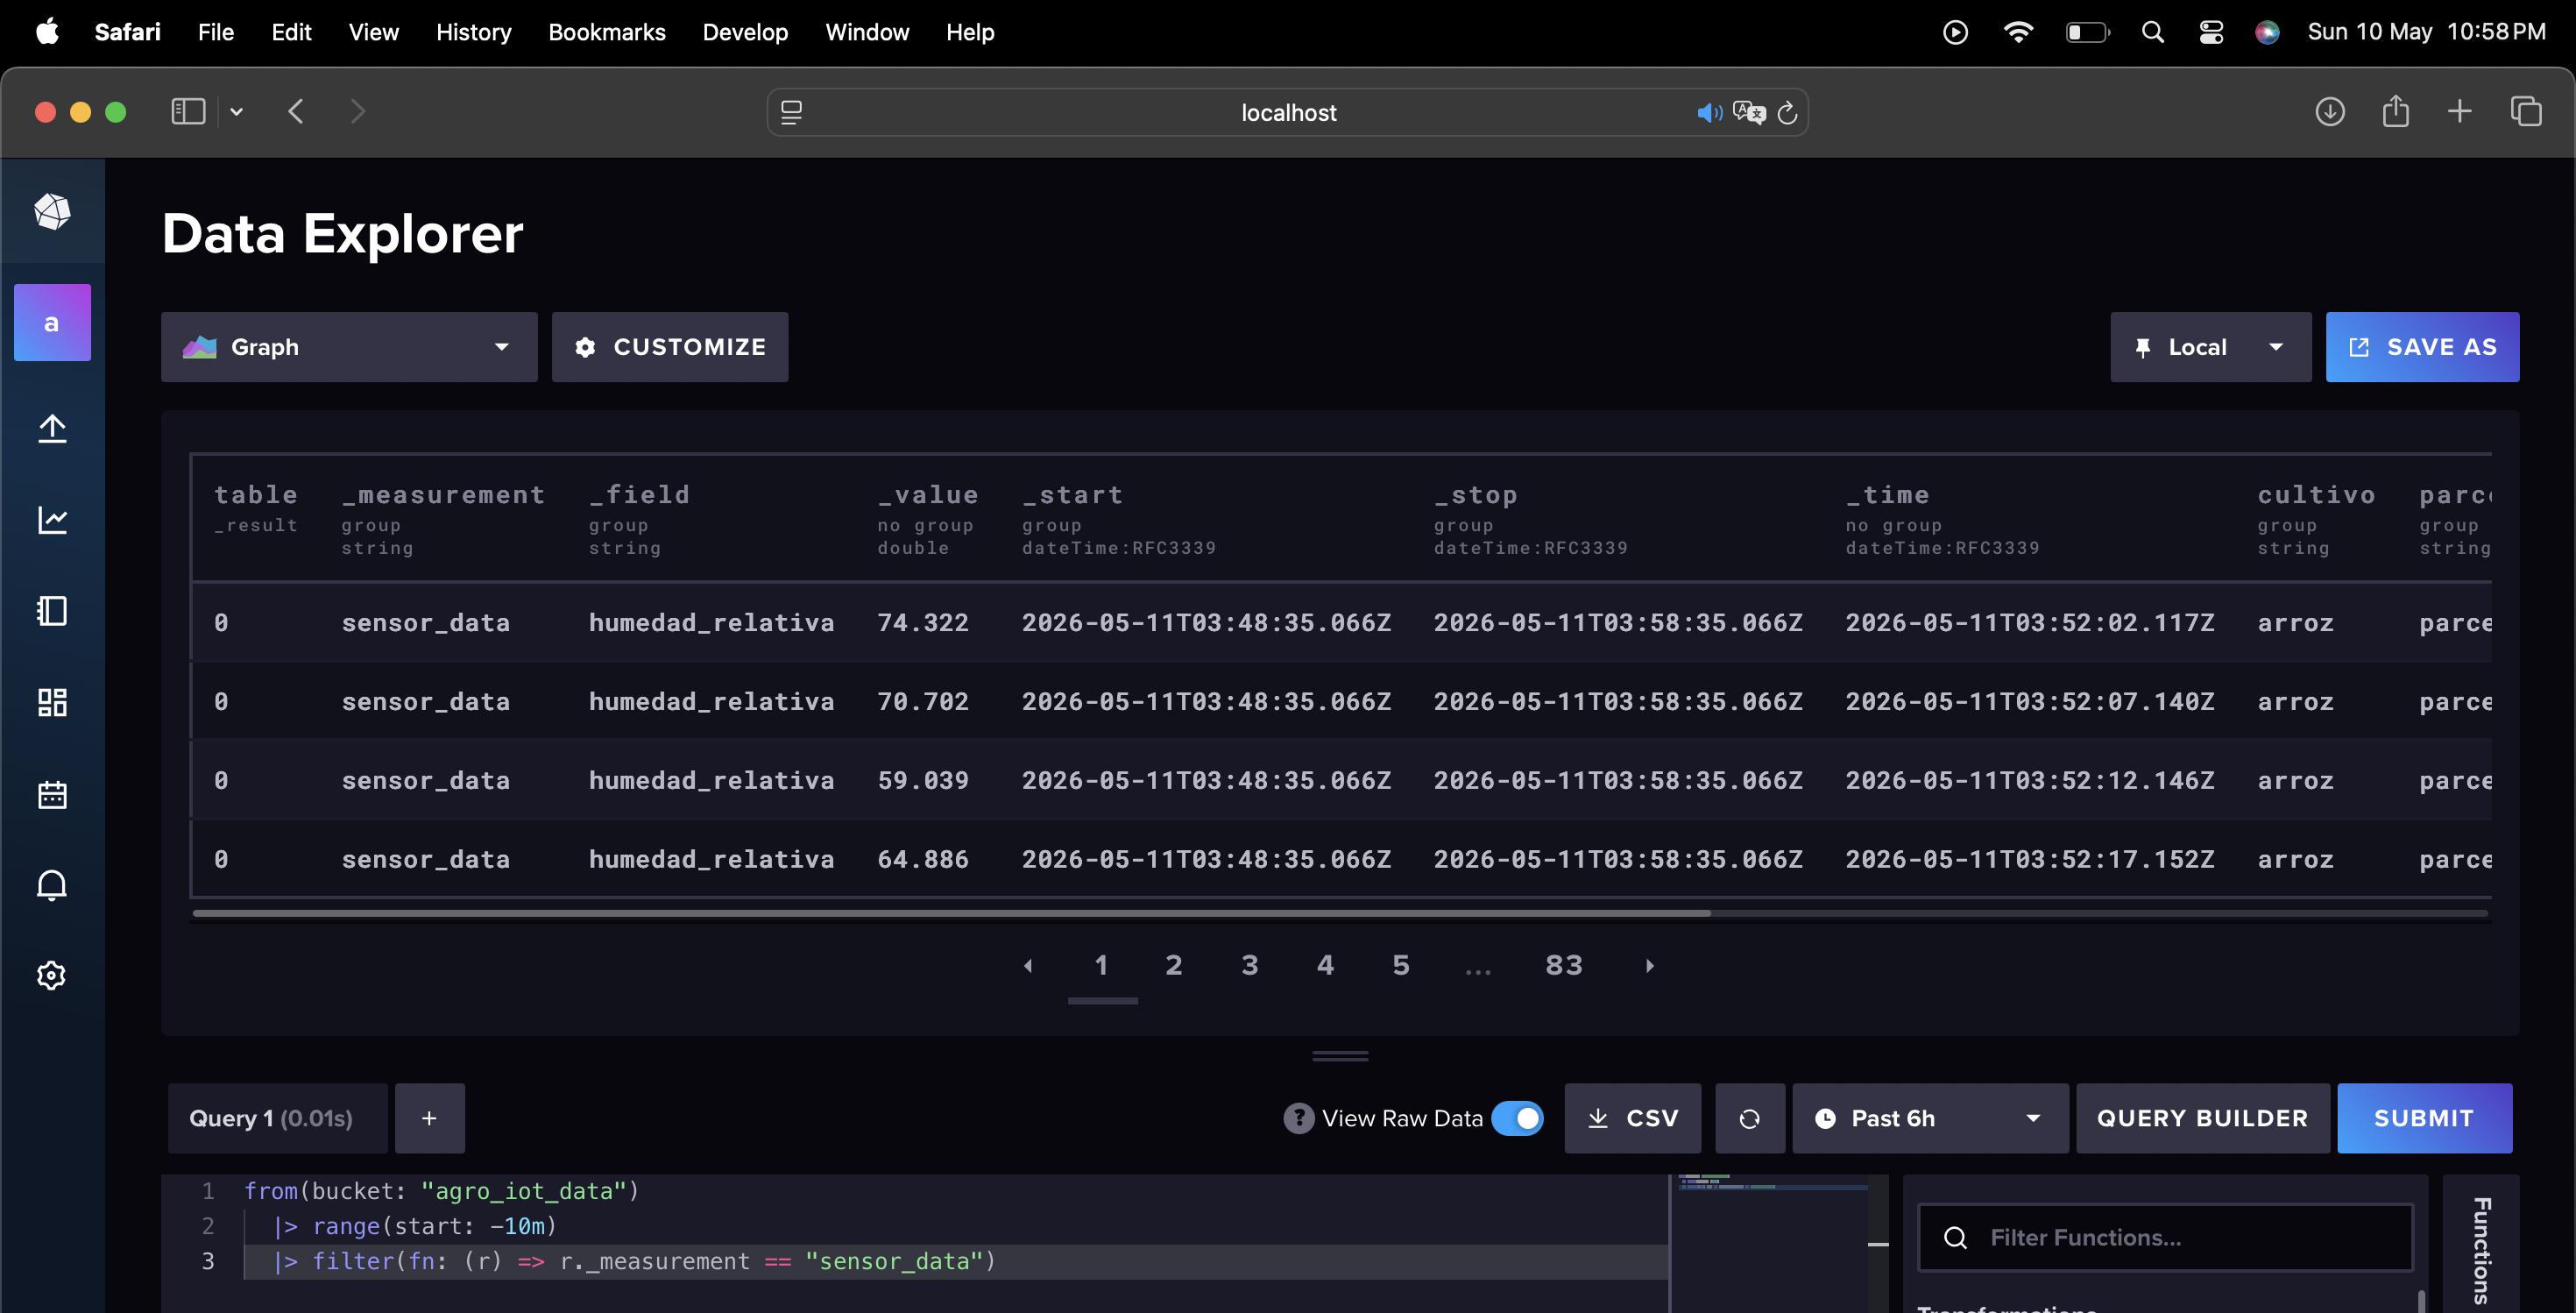


In [ ]:
query_basica = f'''
from(bucket: "{INFLUX_BUCKET}")
  |> range(start: -10m)
  |> filter(fn: (r) => r._measurement == "sensor_data")
  |> limit(n: 20)
'''
print('Query Flux:')
print(query_basica)

try:
    df_basica = client.query_api().query_data_frame(query_basica)
    if isinstance(df_basica, list):
        df_basica = pd.concat(df_basica, ignore_index=True)
    if df_basica.empty:
        print('⚠ Sin datos en la ventana. Asegúrate de que el simulador y Node-RED estén corriendo.')
    else:
        cols_mostrar = [c for c in ['_time', 'parcela', 'cultivo', 'ubicacion',
                                      '_field', '_value', 'unidad']
                          if c in df_basica.columns]
        print(f'Total registros: {len(df_basica)}')
        df_basica[cols_mostrar].head(20)
except Exception as e:
    print(f'⚠ Error en la consulta: {e}')

Query Flux:

from(bucket: "agro_iot_data")
  |> range(start: -10m)
  |> filter(fn: (r) => r._measurement == "sensor_data")
  |> limit(n: 20)

Total registros: 20


### 5.2 Conteo de mensajes por parcela


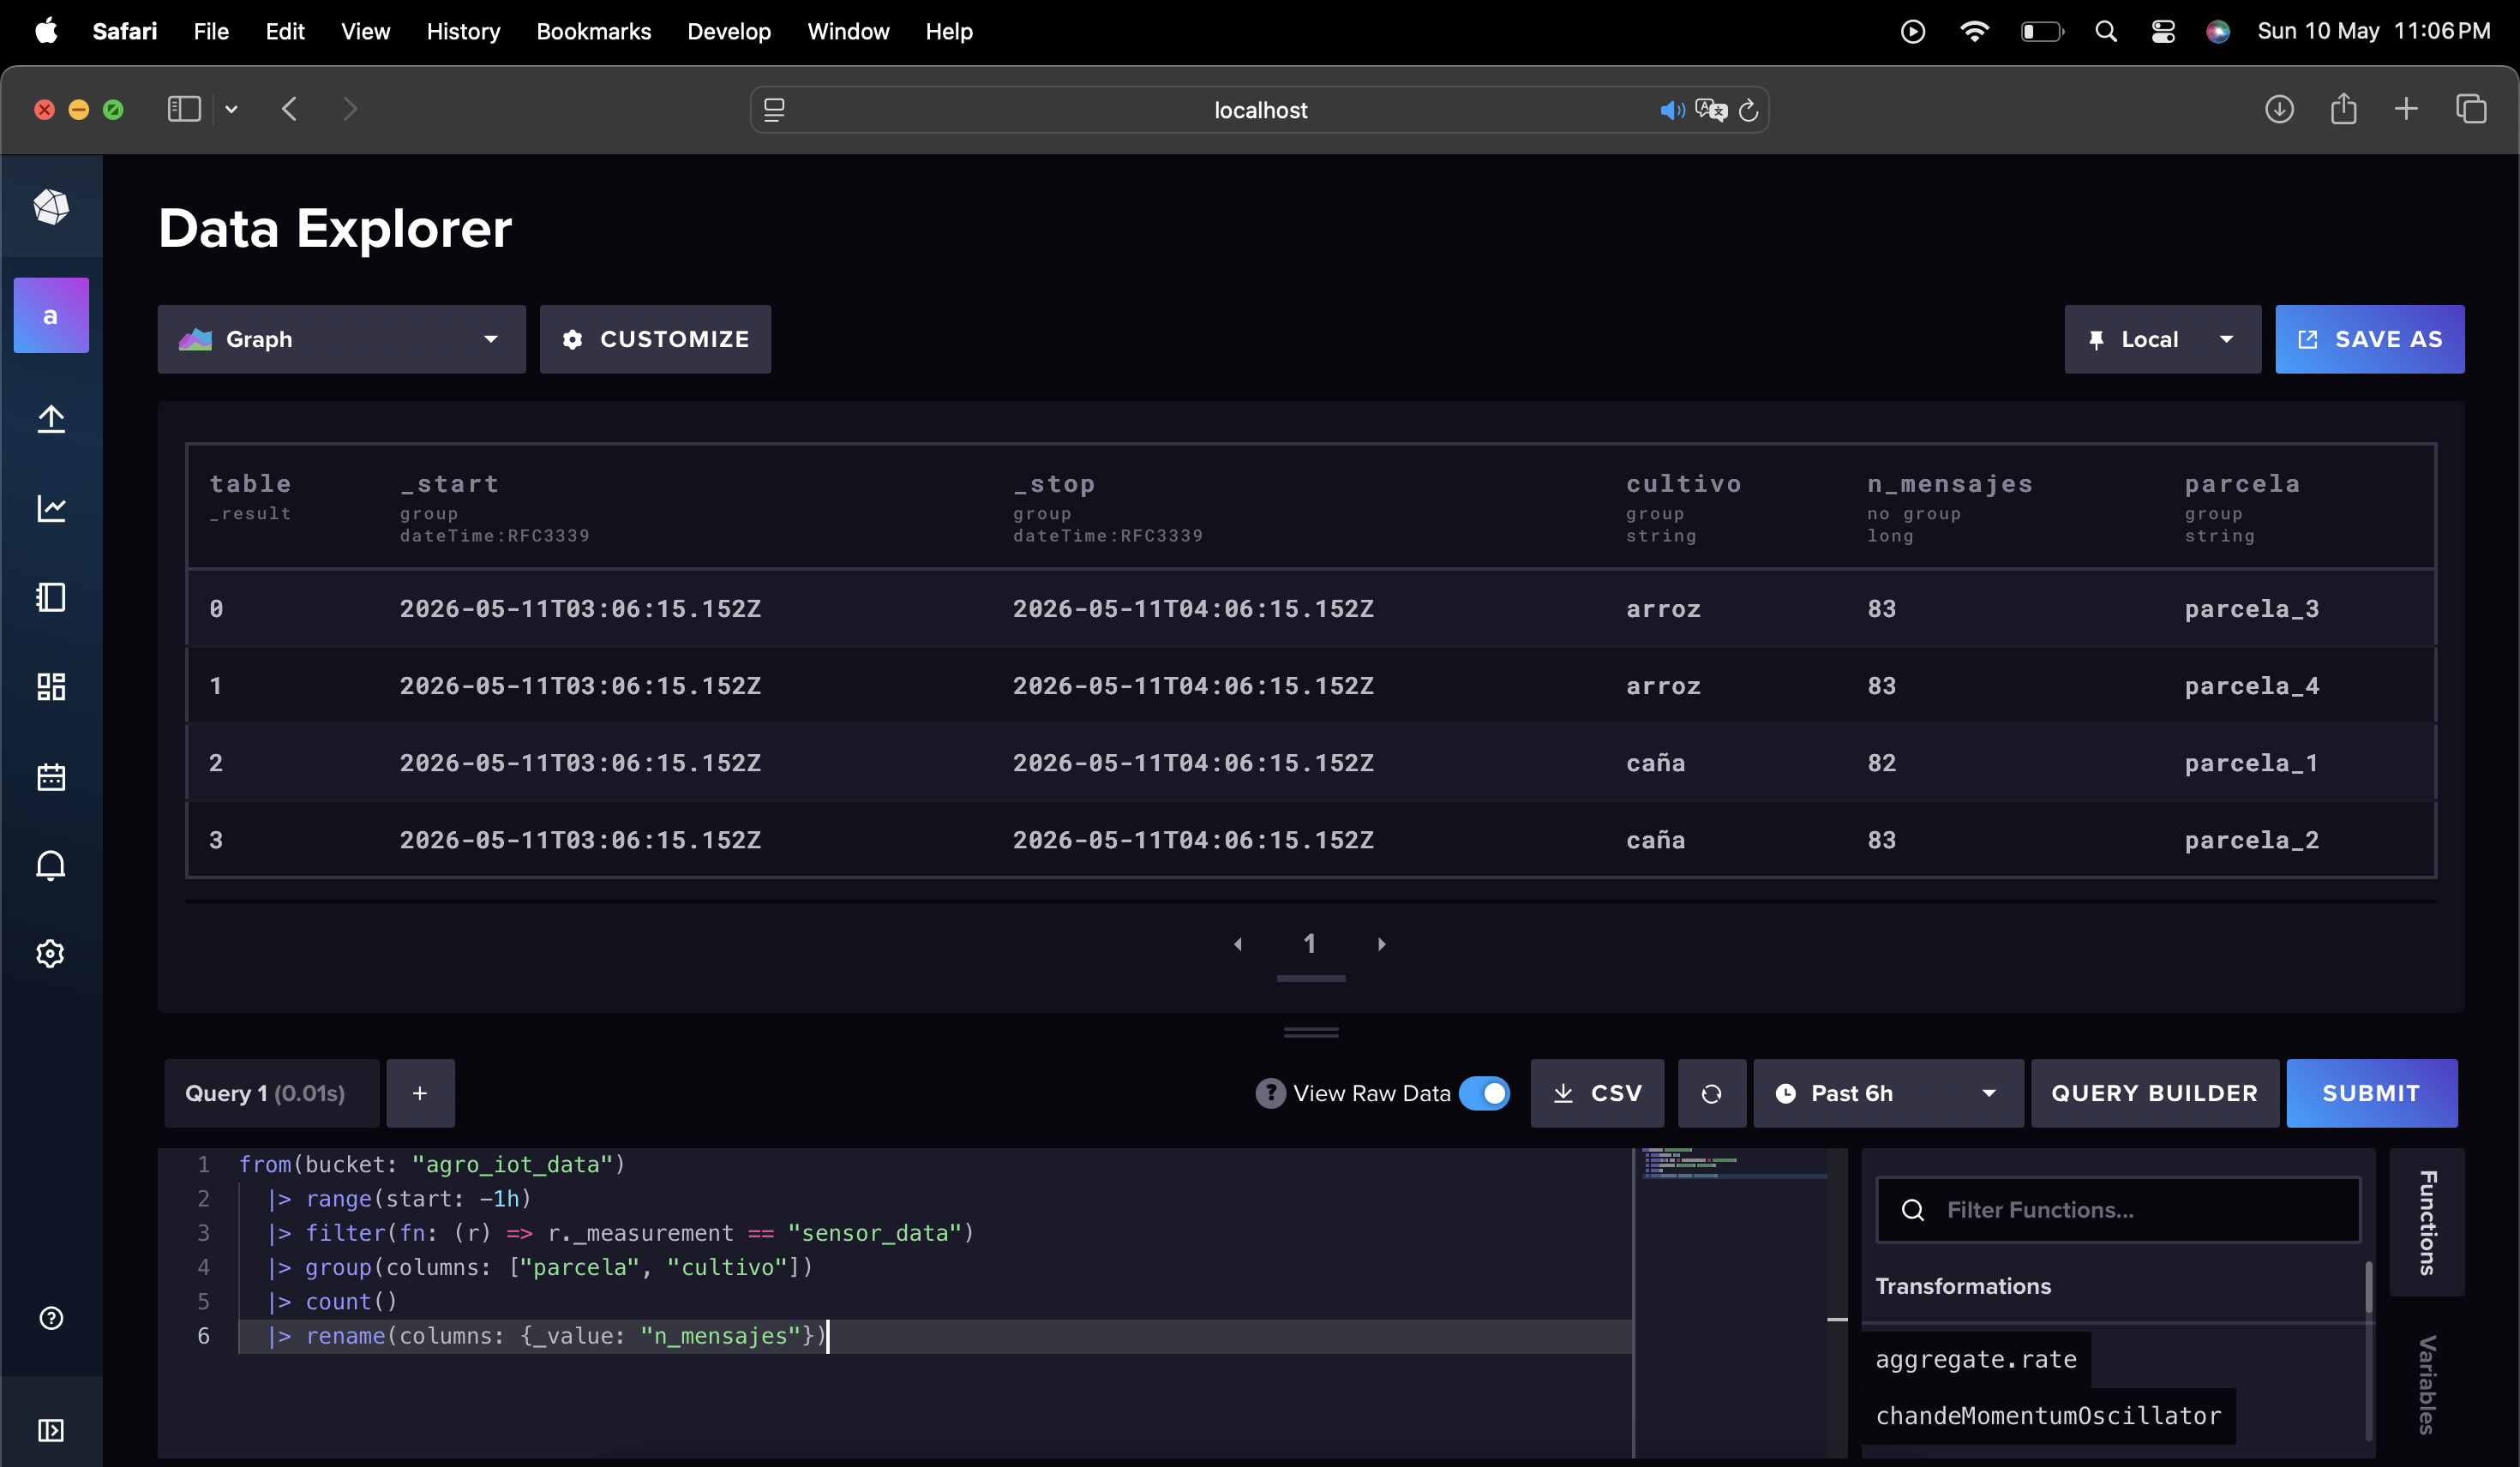


In [ ]:
query_conteo = f'''
from(bucket: "{INFLUX_BUCKET}")
  |> range(start: -1h)
  |> filter(fn: (r) => r._measurement == "sensor_data")
  |> group(columns: ["parcela", "cultivo"])
  |> count()
  |> rename(columns: {{_value: "n_mensajes"}})
'''
print('Query Flux — conteo por parcela:')
print(query_conteo)

try:
    df_conteo = client.query_api().query_data_frame(query_conteo)
    if isinstance(df_conteo, list):
        df_conteo = pd.concat(df_conteo, ignore_index=True)
    if not df_conteo.empty:
        cols = [c for c in ['parcela', 'cultivo', 'n_mensajes'] if c in df_conteo.columns]
        print('\nMensajes por parcela en la última hora:')
        print(df_conteo[cols])
except Exception as e:
    print(f'⚠ Error: {e}')

Query Flux — conteo por parcela:

from(bucket: "agro_iot_data")
  |> range(start: -1h)
  |> filter(fn: (r) => r._measurement == "sensor_data")
  |> group(columns: ["parcela", "cultivo"])
  |> count()
  |> rename(columns: {_value: "n_mensajes"})


Mensajes por parcela en la última hora:
     parcela cultivo  n_mensajes
0  parcela_1    caña         220
1  parcela_2    caña         218
2  parcela_3   arroz         224
3  parcela_4   arroz         219


### 5.3 Temperatura promedio por parcela (la consulta-evidencia)


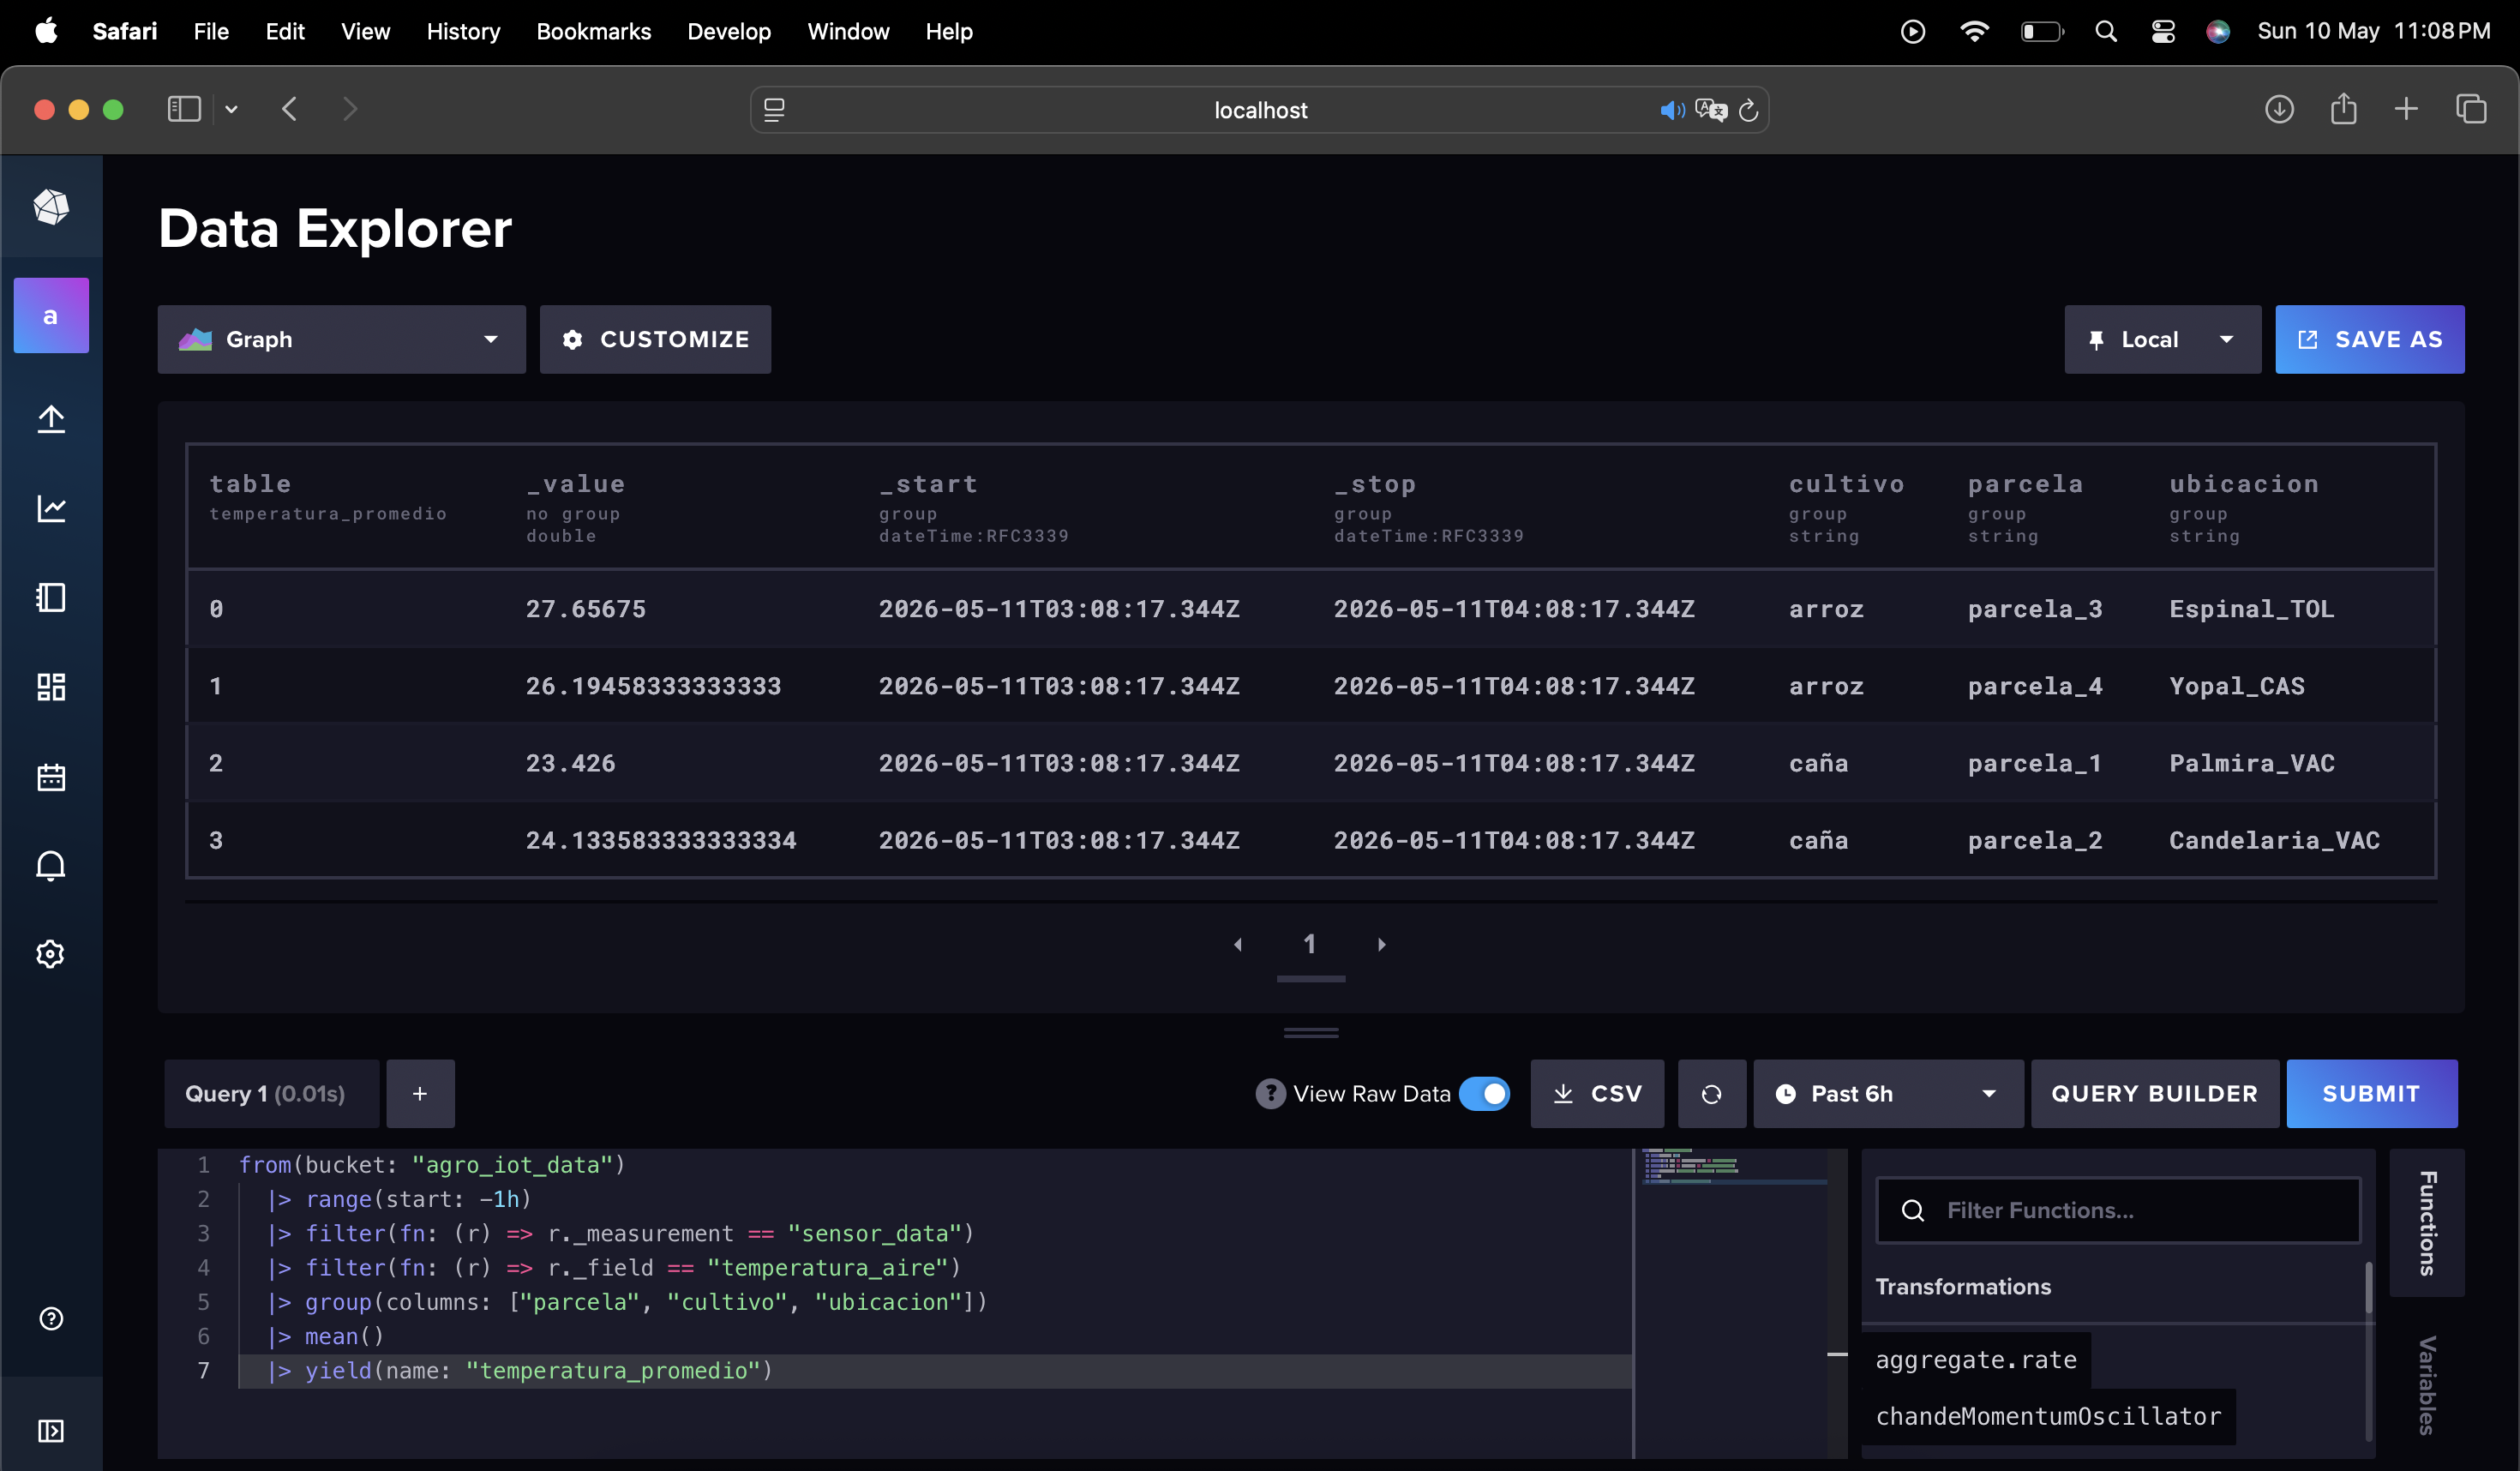


In [ ]:
query_temp_promedio = f'''
from(bucket: "{INFLUX_BUCKET}")
  |> range(start: -1h)
  |> filter(fn: (r) => r._measurement == "sensor_data")
  |> filter(fn: (r) => r._field == "temperatura_aire")
  |> group(columns: ["parcela", "cultivo", "ubicacion"])
  |> mean()
  |> yield(name: "temperatura_promedio")
'''
print('Query Flux — temperatura promedio por parcela:')
print(query_temp_promedio)

try:
    df_temp = client.query_api().query_data_frame(query_temp_promedio)
    if isinstance(df_temp, list):
        df_temp = pd.concat(df_temp, ignore_index=True)
    if not df_temp.empty:
        cols = [c for c in ['parcela', 'cultivo', 'ubicacion', '_value'] if c in df_temp.columns]
        df_temp_show = df_temp[cols].rename(columns={'_value': 'T_promedio_C'})
        print('\nResultado:')
        print(df_temp_show.round(2))
except Exception as e:
    print(f'⚠ Error: {e}')

Query Flux — temperatura promedio por parcela:

from(bucket: "agro_iot_data")
  |> range(start: -1h)
  |> filter(fn: (r) => r._measurement == "sensor_data")
  |> filter(fn: (r) => r._field == "temperatura_aire")
  |> group(columns: ["parcela", "cultivo", "ubicacion"])
  |> mean()
  |> yield(name: "temperatura_promedio")


Resultado:
     parcela cultivo       ubicacion  T_promedio_C
0  parcela_1    caña     Palmira_VAC         23.97
1  parcela_2    caña  Candelaria_VAC         24.17
2  parcela_3   arroz     Espinal_TOL         27.34
3  parcela_4   arroz       Yopal_CAS         26.70


### 5.4 Series temporales: precipitación última hora


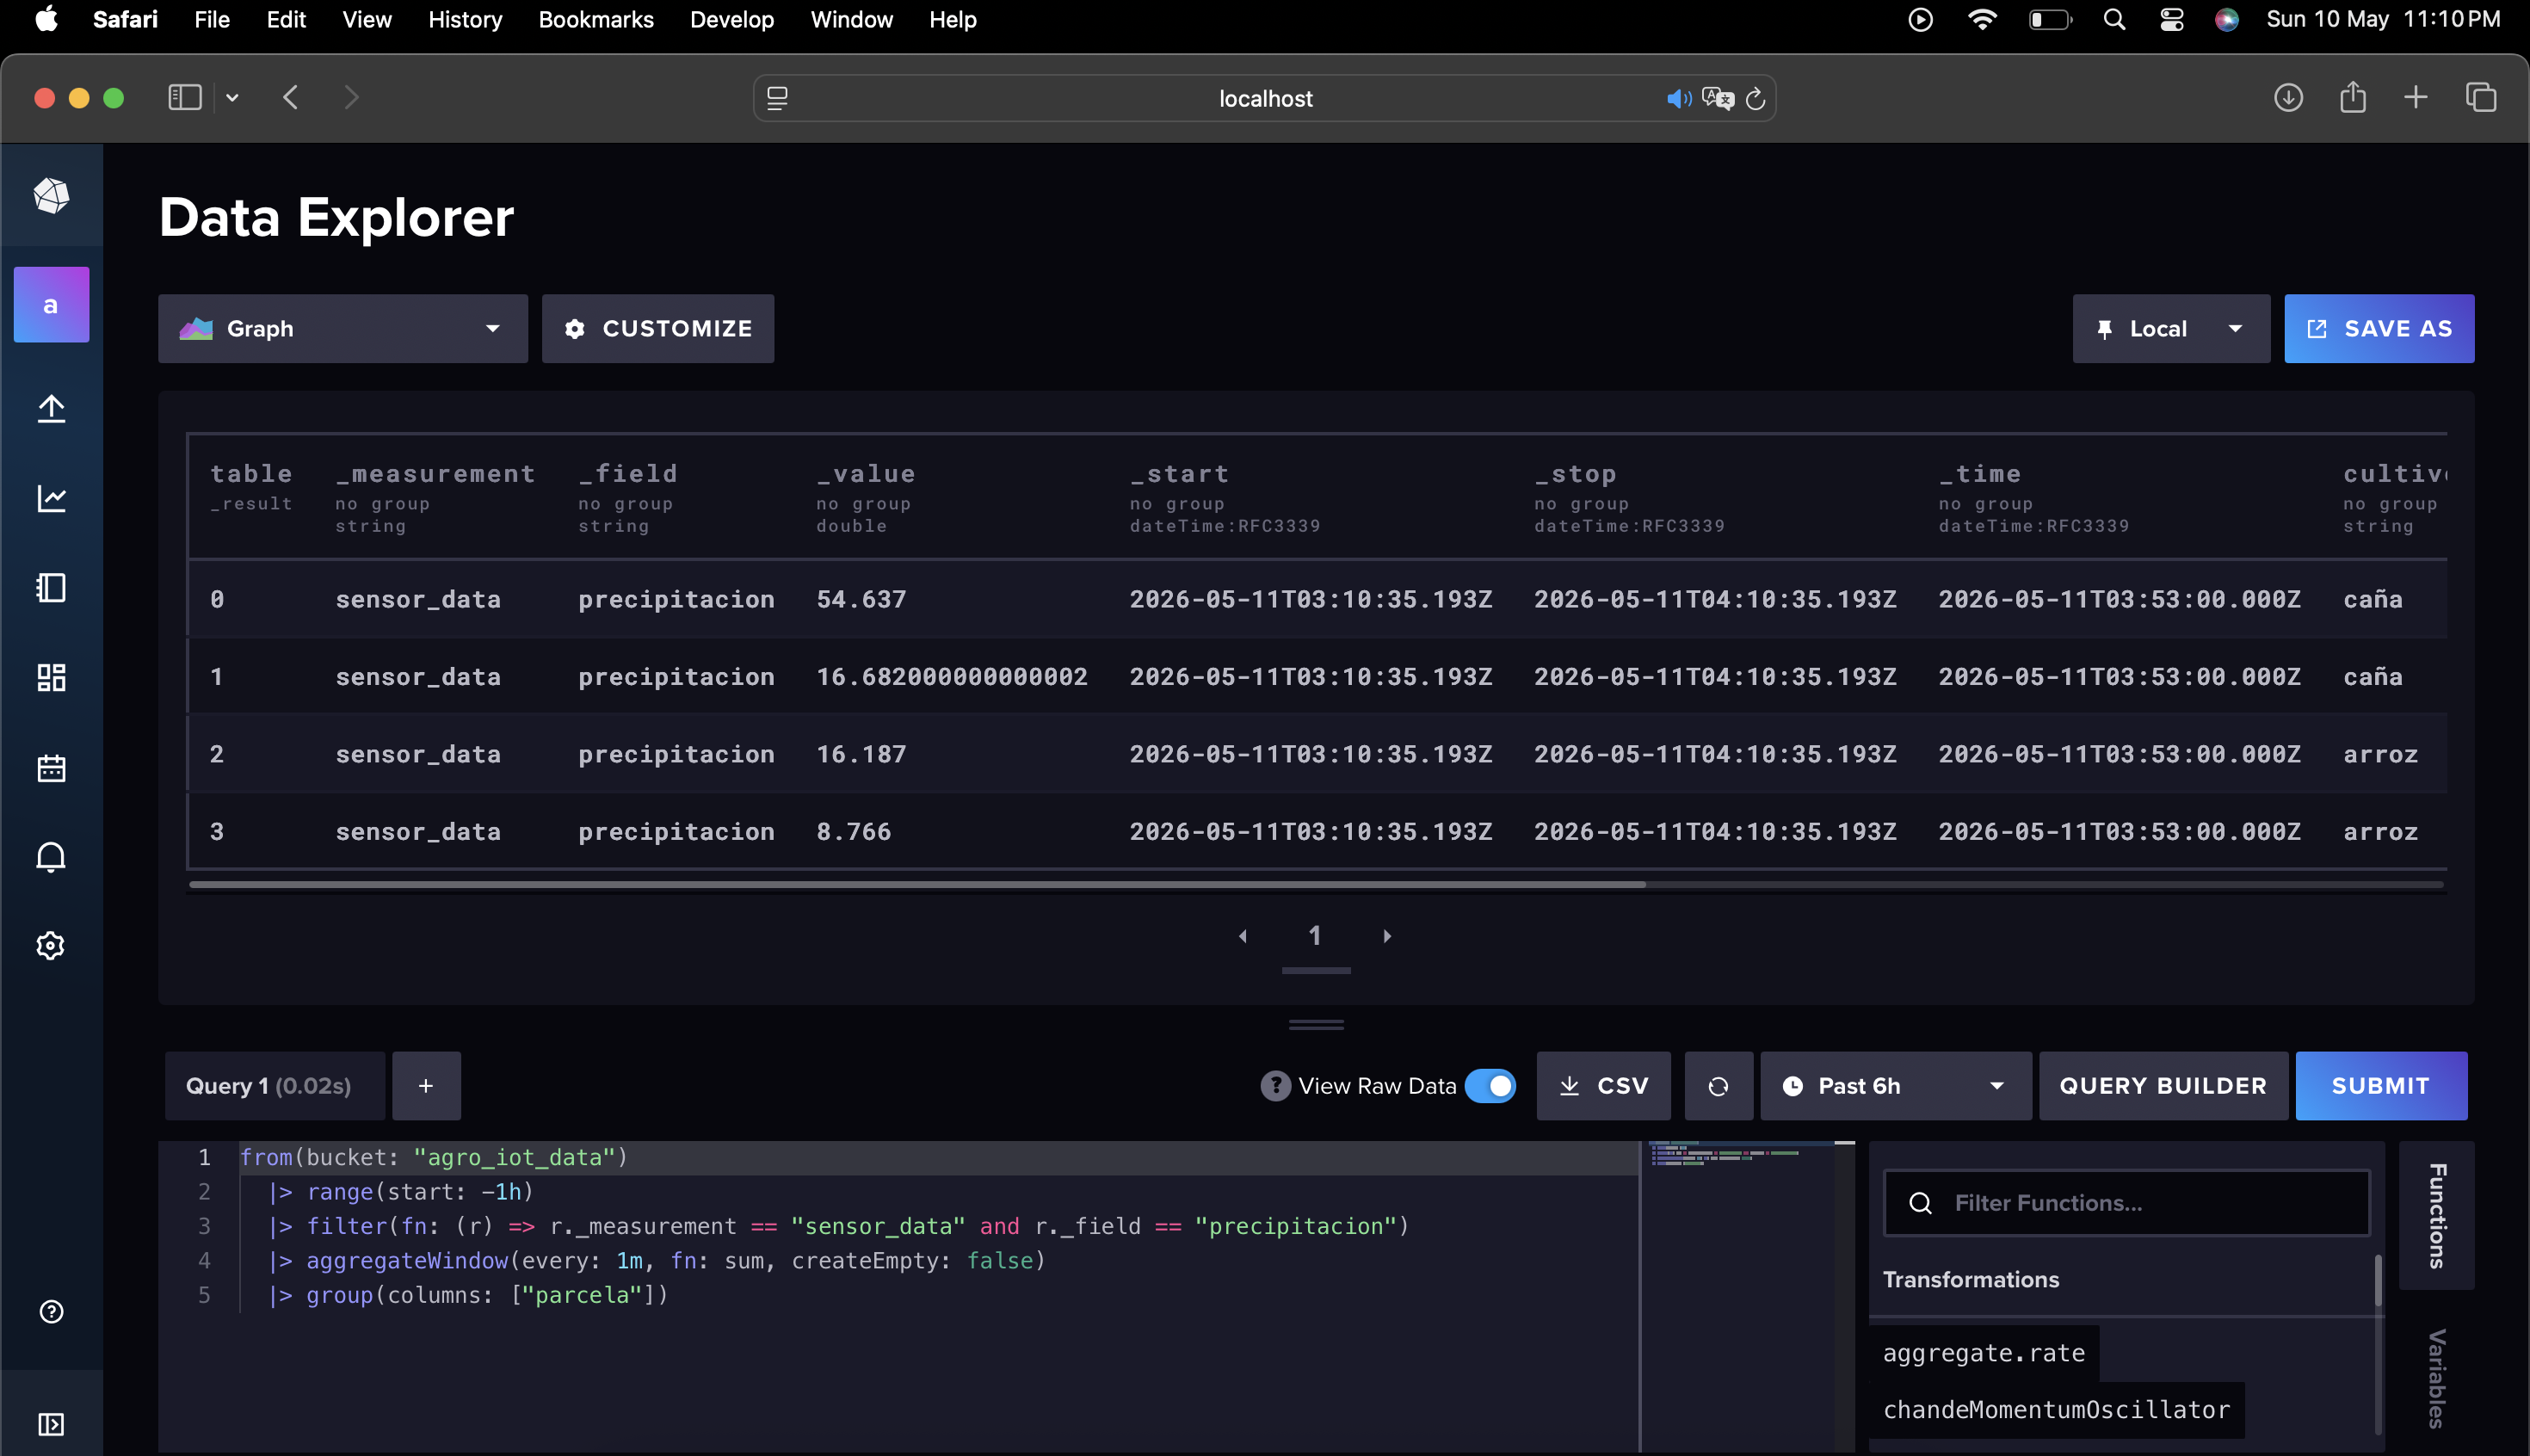


In [ ]:
query_prec = f'''
from(bucket: "{INFLUX_BUCKET}")
  |> range(start: -1h)
  |> filter(fn: (r) => r._measurement == "sensor_data" and r._field == "precipitacion")
  |> aggregateWindow(every: 1m, fn: sum, createEmpty: false)
  |> group(columns: ["parcela"])
'''
print('Query Flux — precipitación agregada por minuto y parcela:')
print(query_prec)

try:
    df_prec = client.query_api().query_data_frame(query_prec)
    if isinstance(df_prec, list):
        df_prec = pd.concat(df_prec, ignore_index=True)
    if not df_prec.empty:
        print(f'Total puntos agregados: {len(df_prec)}')
        df_prec[['_time', 'parcela', '_value']].head(15)
except Exception as e:
    print(f'⚠ Error: {e}')

Query Flux — precipitación agregada por minuto y parcela:

from(bucket: "agro_iot_data")
  |> range(start: -1h)
  |> filter(fn: (r) => r._measurement == "sensor_data" and r._field == "precipitacion")
  |> aggregateWindow(every: 1m, fn: sum, createEmpty: false)
  |> group(columns: ["parcela"])

Total puntos agregados: 15


---
## 6. Evidencias
Luego de correr el flujo , estas fueron las capturas de los resultados:

### 6.1 Captura del flow Node-RED (Entregable 1)

1. Node-RED en `http://localhost:1880`.
2. Se ve la pestaña **Fase 3** esta visible con todos los nodos conectados.

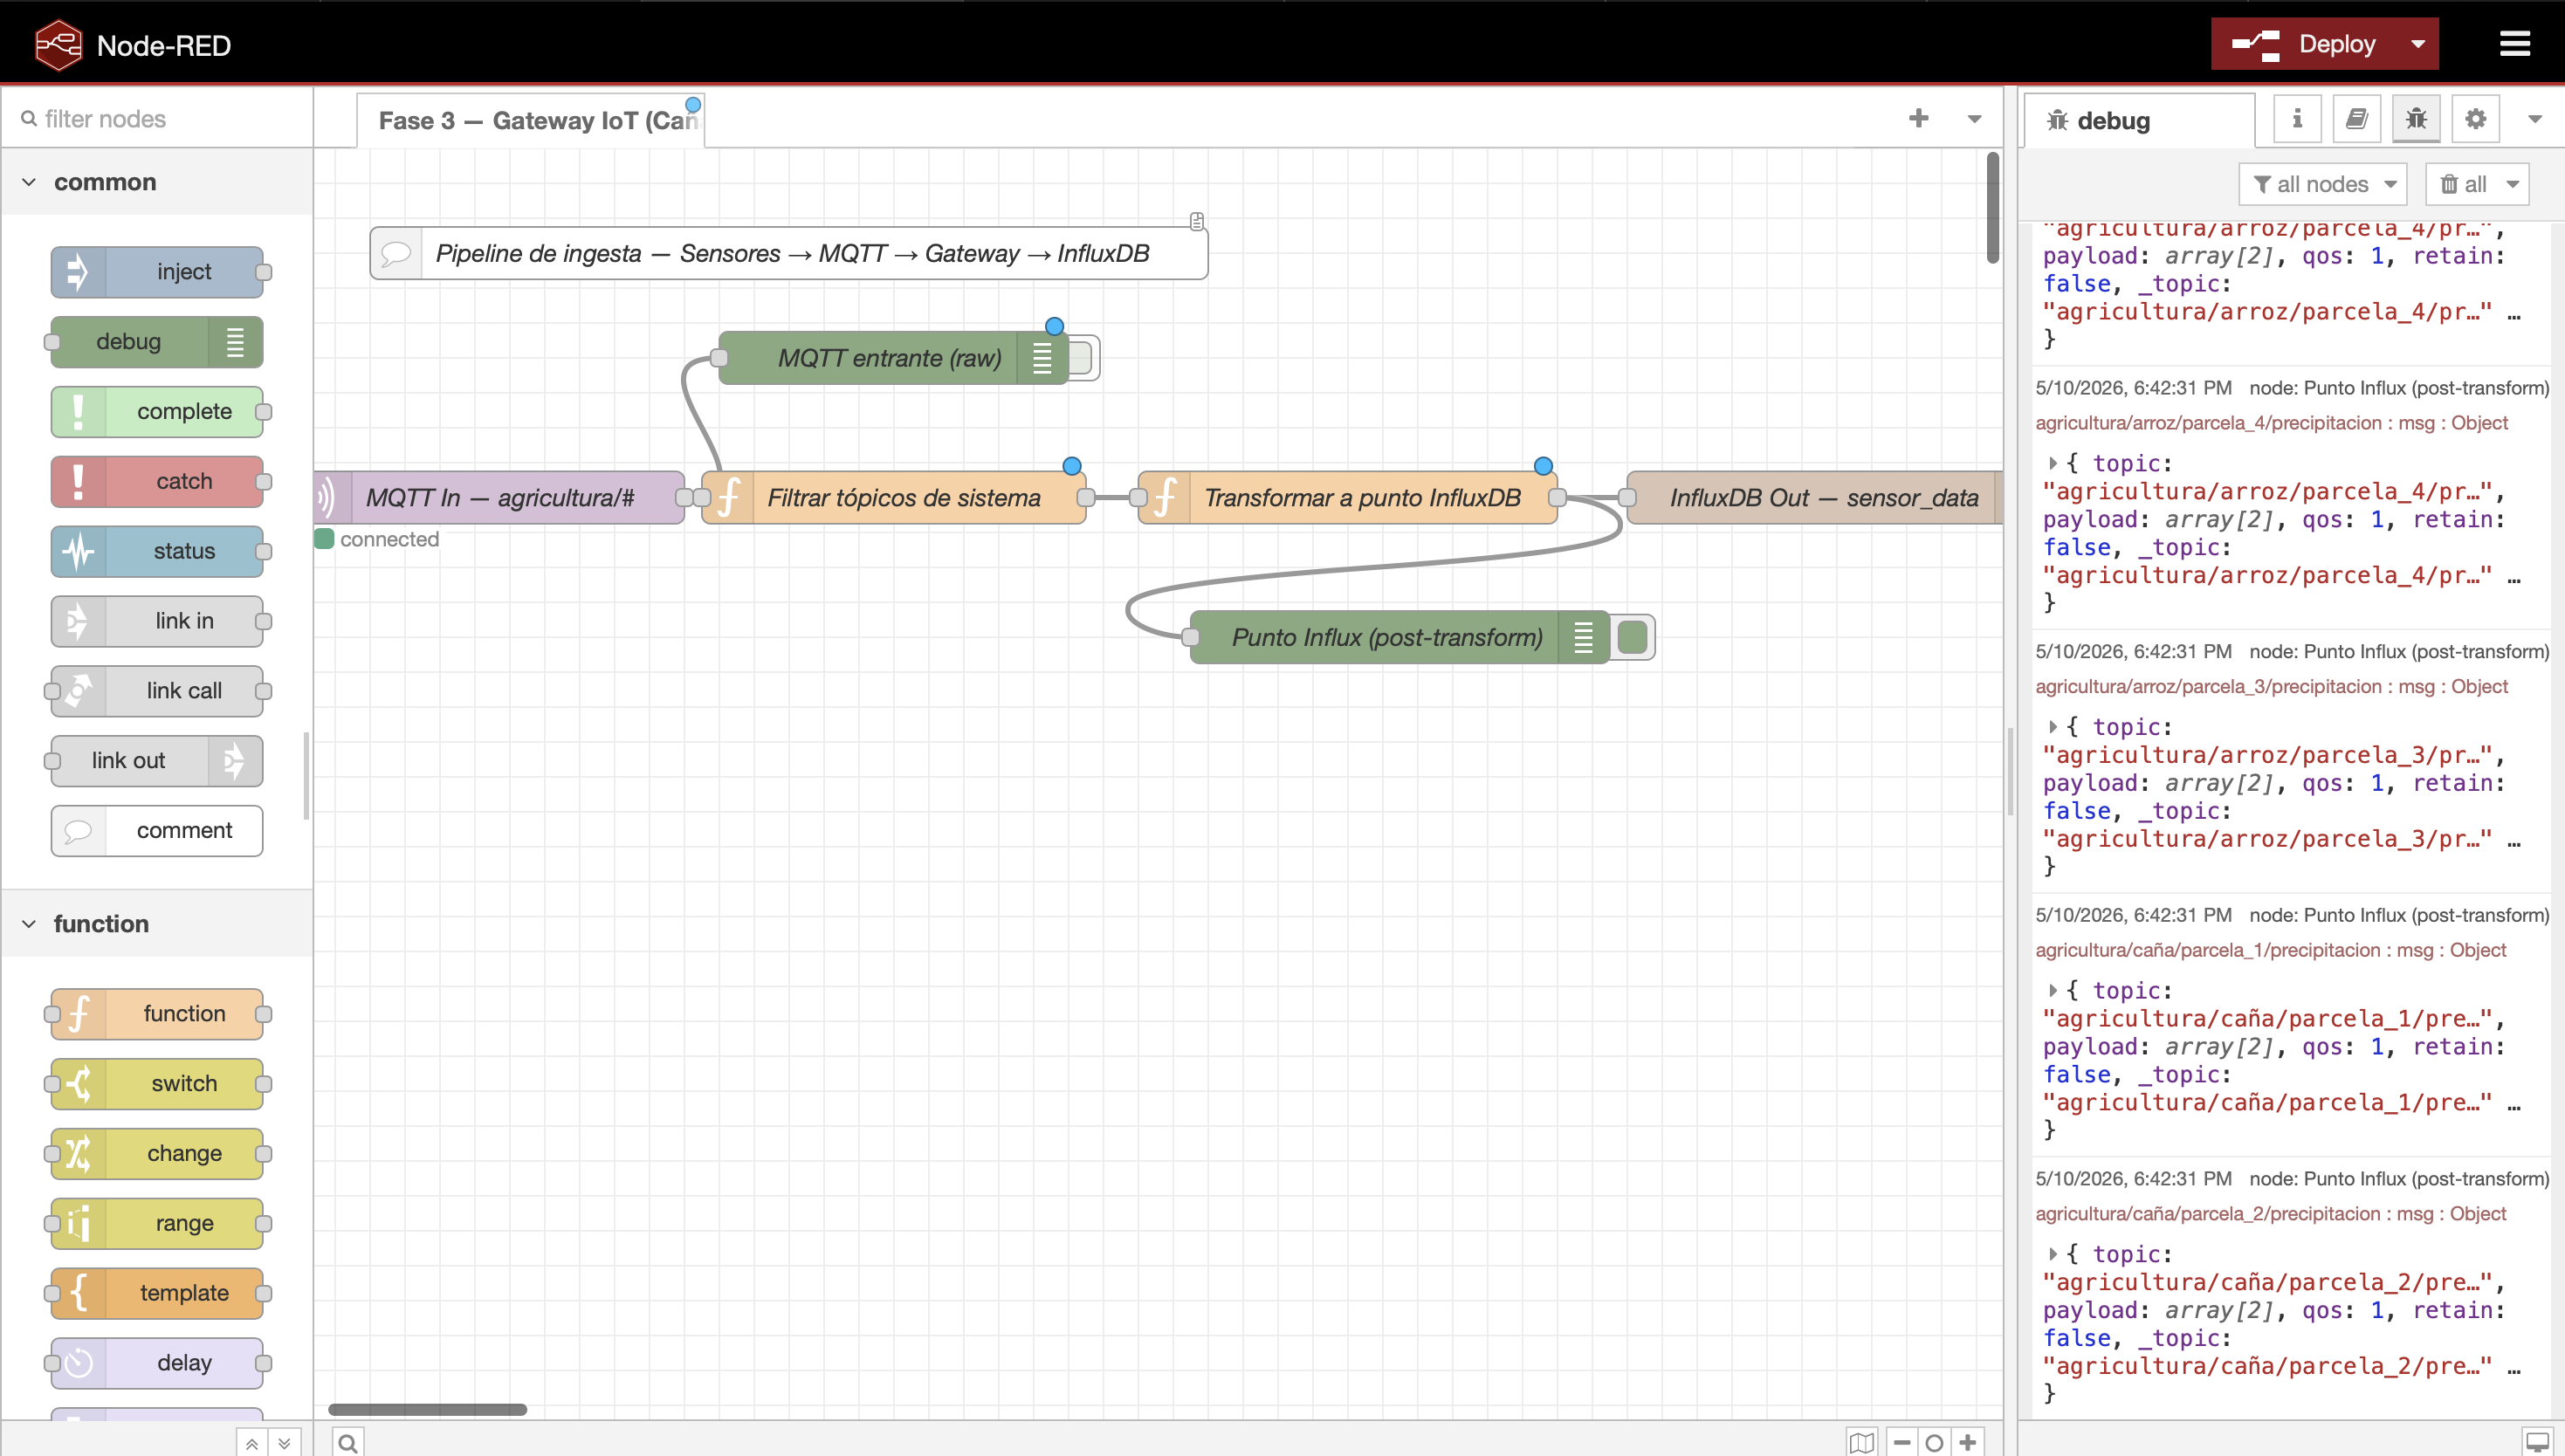

### 6.2 Configuración de Mosquitto (Entregable 2)

```bash
cat /opt/homebrew/etc/mosquitto/mosquitto.conf
brew services list | grep mosquitto
lsof -iTCP:1883 -sTCP:LISTEN
```

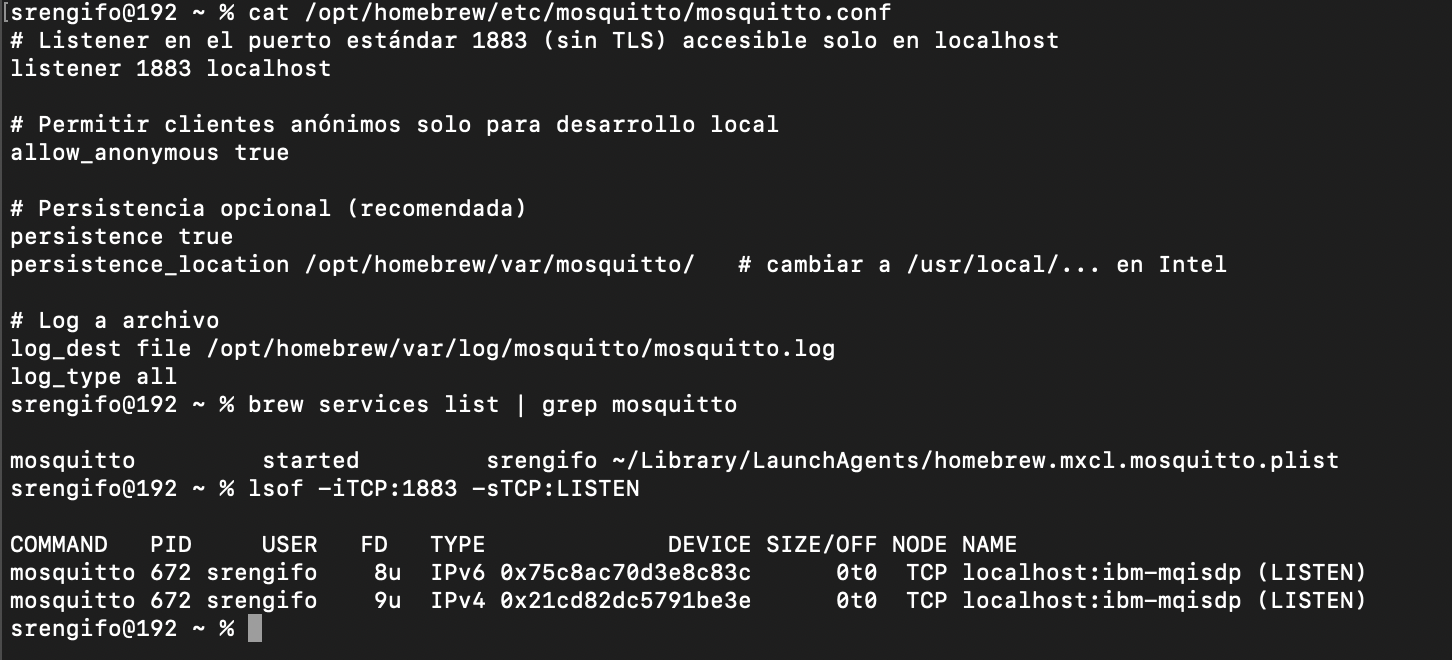

### 6.3 Bucket creado en InfluxDB (Entregable 3)

1. En `http://localhost:8086` → **Load Data → Buckets**.
2. Se ve el bucket `agro_iot_data` en la lista.

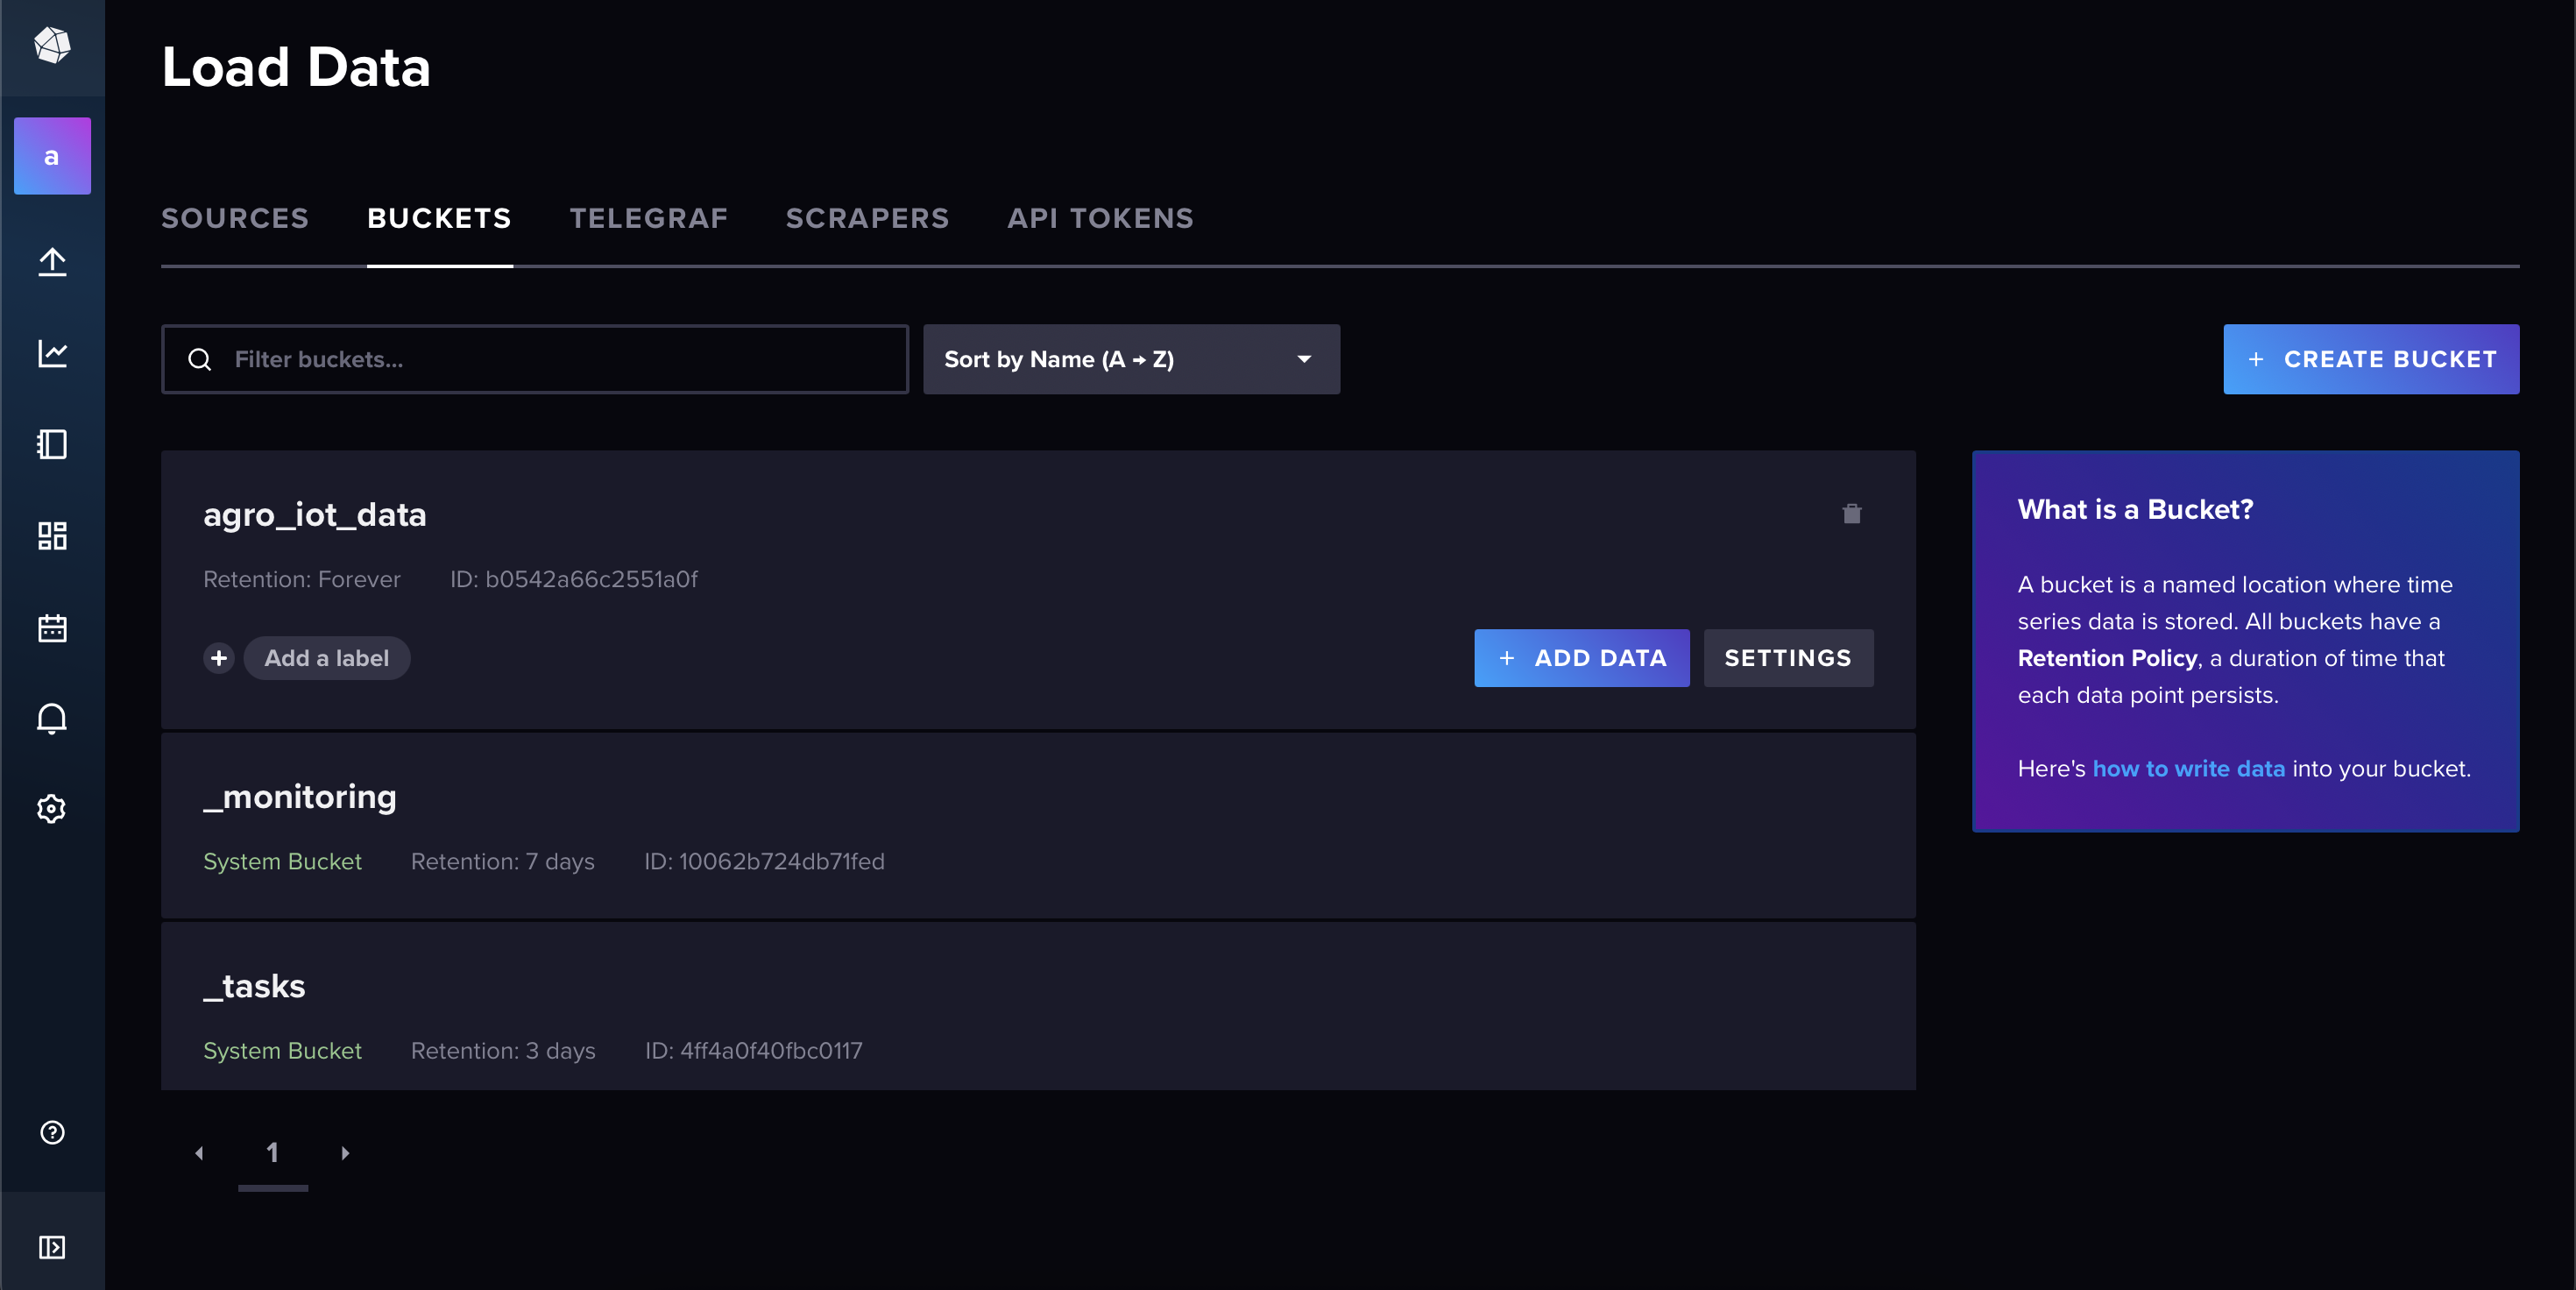

### 6.4 Datos almacenados (Entregable 4)

1. En **Data Explorer**.
2. Se construye una consulta sobre `agro_iot_data` filtrando por `_measurement == sensor_data`.
3. Esta es la tabla de resultados.

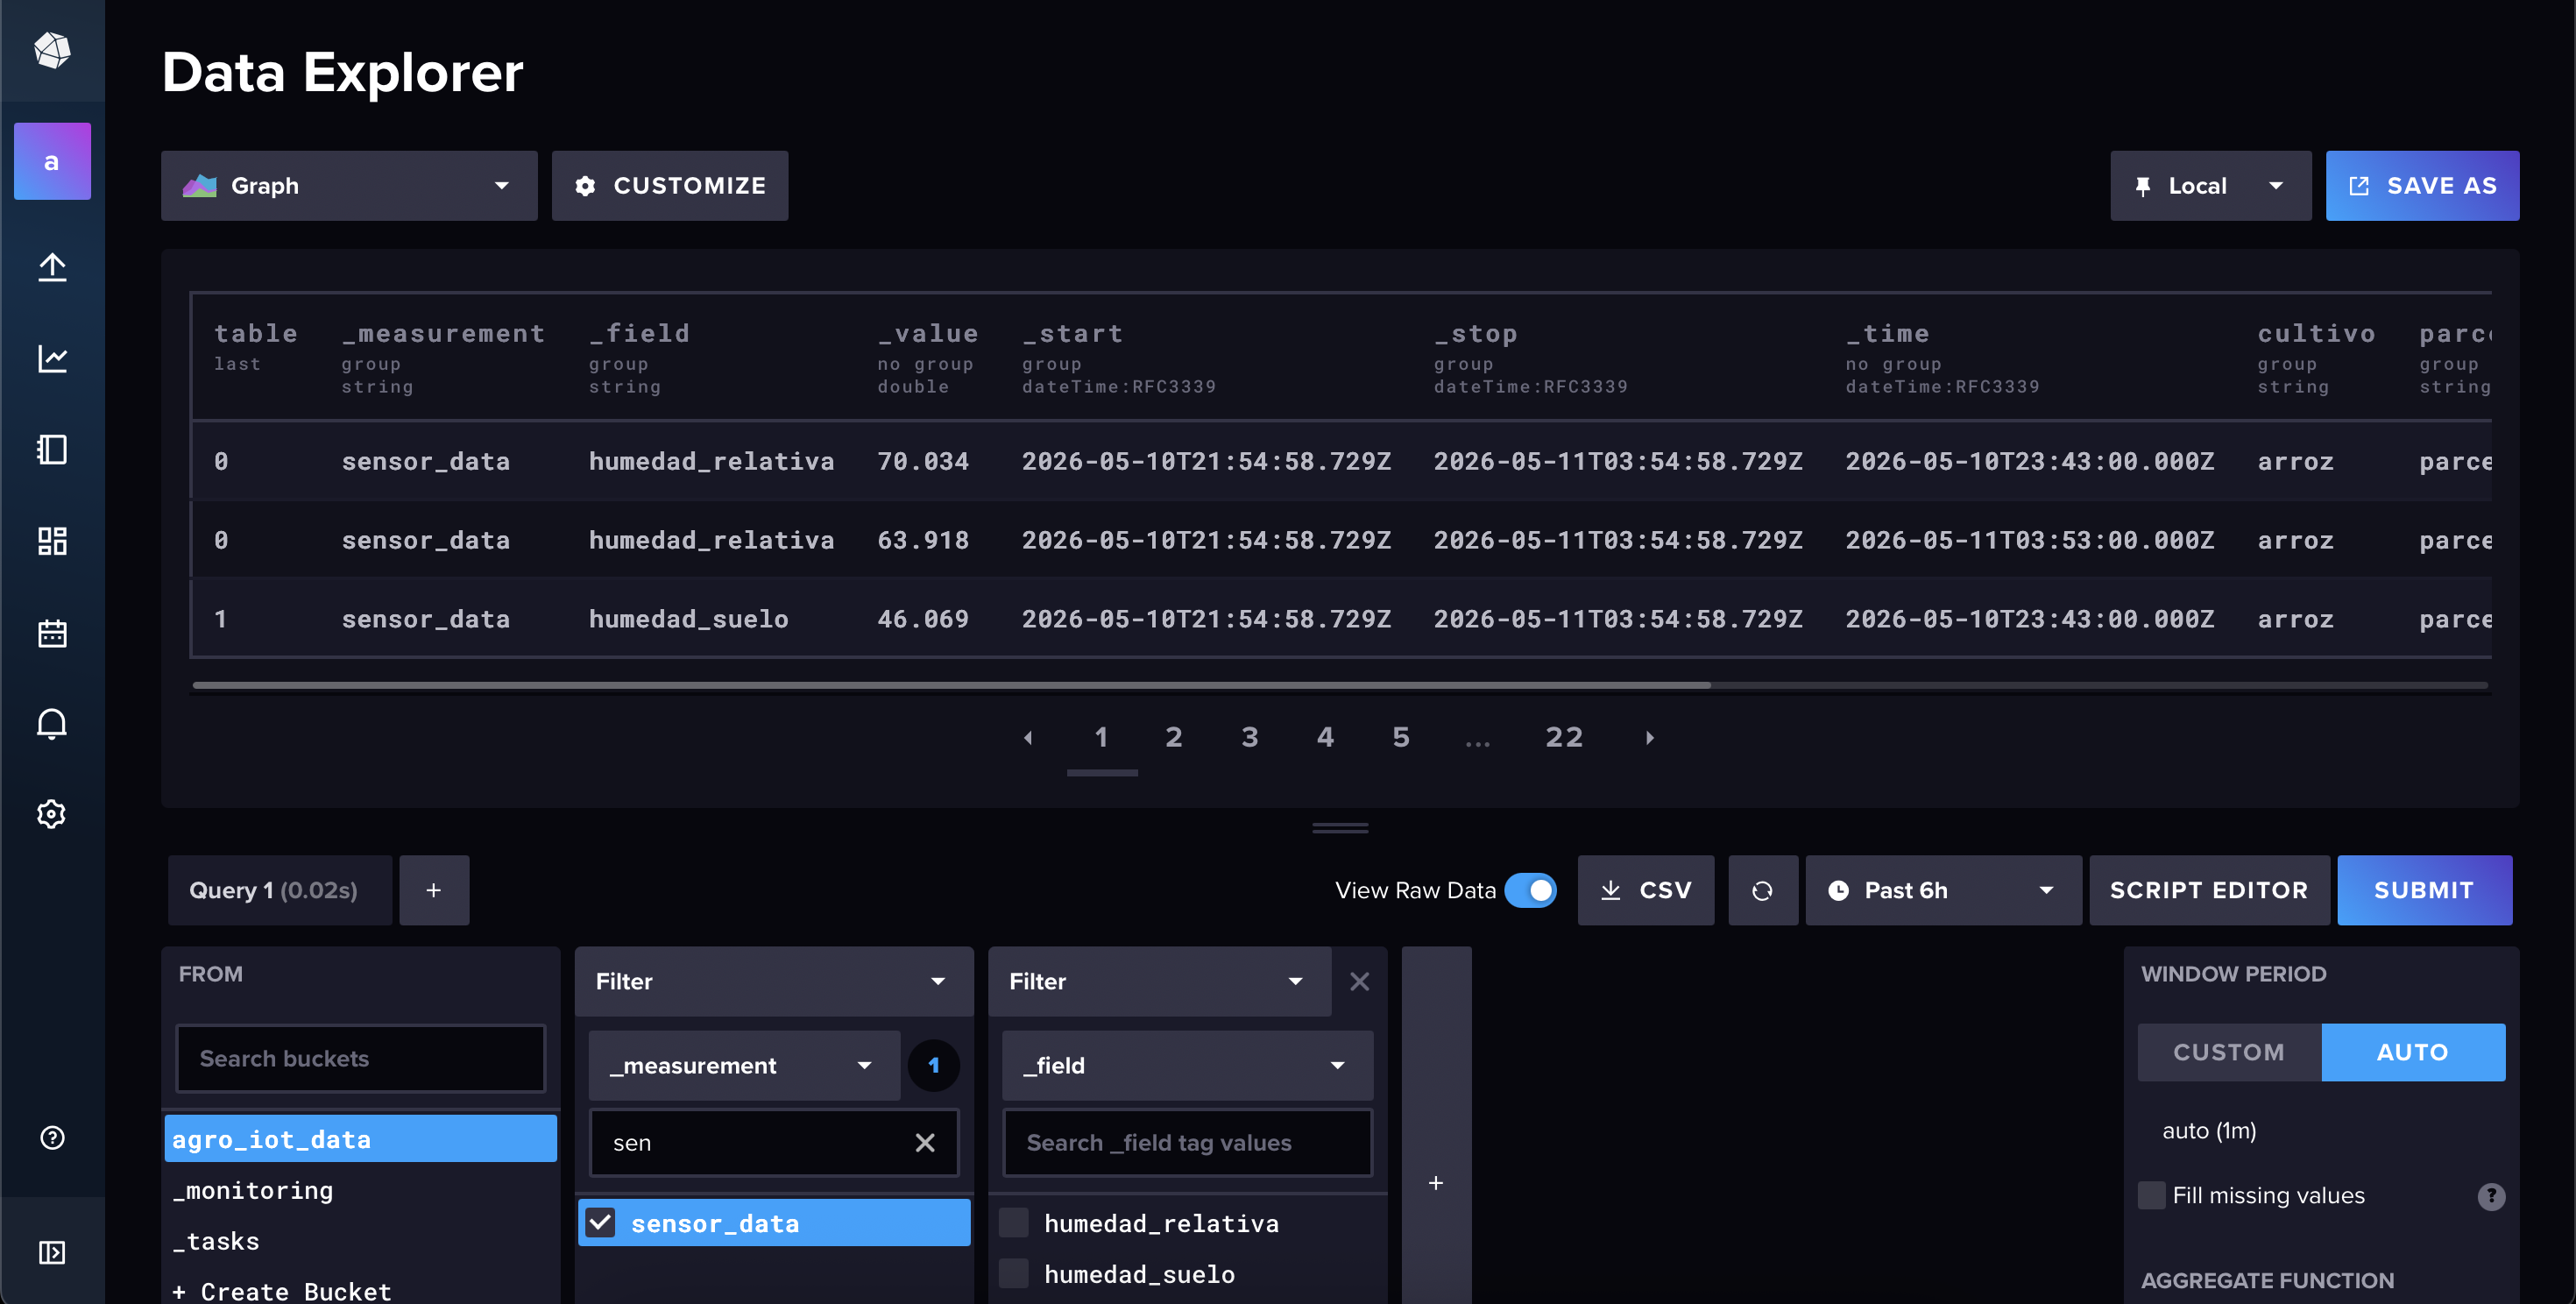

### 6.5 Consulta Flux con resultados (Entregable 5)

El output de las celdas 5.1-5.3 de este notebook ya constituye evidencia válida del Entregable 5.

---
## 7. Conclusiones de la Fase 3 y siguiente paso

### Logros

1. **Pipeline E2E funcionando:** sensores virtuales → MQTT → Node-RED → InfluxDB, sin pérdida de mensajes y con timestamps preservados.
2. **Modelado de datos:** se eligió el patrón `measurement=sensor_data` con campos dinámicos por variable y tags (`parcela`, `cultivo`, `ubicacion`, `variable`), lo cual permite consultas eficientes por cualquier dimensión.
3. **Adaptación al formato real:** la función Node-RED se ajustó al formato de mensajes de la Fase 2 (un mensaje por sensor por variable, con `valor` numérico y metadatos en el payload). Esta es la práctica IoT correcta — cada sensor publica de forma independiente con su propia cadencia.
4. **Compatibilidad con Fase 7:** Grafana, que se usará en la Fase 7, puede leer directamente del bucket `agro_iot_data` con las mismas credenciales — no se requiere cambio alguno.

### Diferencias respecto a la guia del proyecto final

El PDF de la Fase 3 muestra un payload de ejemplo donde TODAS las variables vienen en un único mensaje JSON:
```json
{ "temperature_air": 24.5, "humidity": 75.2, "precipitation": 0.0, "soil_ph": 6.8, ... }
```
Nuestro simulador (Fase 2) sigue el patrón **un mensaje por variable**, que es agronómicamente más correcto: cada sensor publica a su propia frecuencia (T° cada 5 min, pH cada 1 h, precipitación por evento, etc.). El flow Node-RED se adaptó a esta realidad mediante un **field dinámico** cuyo nombre coincide con `payload.variable`. Esto permite escalar el sistema a más sensores sin cambiar el flow.

### Recomendaciones para la Fase 4 (Procesamiento en tiempo real)

- **Tasks en InfluxDB:** definir `tasks` Flux que rellenen un bucket secundario (`agro_iot_data_aggregated`) con promedios horarios y diarios.
- **Detección de outliers en Node-RED:** añadir un nodo function adicional que marque valores fuera de rango (por ejemplo T°<15°C o T°>40°C) y los enrute a un tópico MQTT secundario `agricultura/alertas/+`.

---

**Fin de la Fase 3.** El siguiente paso es la **Fase 4 — Procesamiento de datos en tiempo real**.